In [2]:
path = "/Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP"
path_red = "/Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pymatgen.core import Structure
import matgl
from matgl.ext.pymatgen import Structure2Graph

In [3]:
data = pd.read_csv("/Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP/3DSC_MP.csv", skiprows=1)
#print(data.columns)
print(data.loc[0,'tc'])
print(data.loc[0,'cif'])

2.64
data/final/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif


In [2]:
!pip install matgl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 13.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 13.2 MB/s  0:00:00 21.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.9 MB/s  0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [matgl];5;237m━━━ 11/12 [matgl]ub]ightning]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires p

In [4]:
structure = Structure.from_file(path_red +'/' + data.loc[0,'cif'])
structure

FileNotFoundError: [Errno 2] No such file or directory: '/Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP/data/final/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif'

In [5]:
import os
from pymatgen.core import Structure

# 1. Point directly to the 'cifs' folder shown in your screenshot
path_cifs = "/Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP/cifs"

# 2. Get the raw string from the dataframe
raw_cif_string = data.loc[0, 'cif']

# 3. Use os.path.basename to strip away the authors' old path and keep ONLY the filename 
# (e.g., it turns "data/final/MP/cifs/Ag0.02...cif" into just "Ag0.02...cif")
filename = os.path.basename(raw_cif_string)

# 4. Safely join your local path with the clean filename
full_local_path = os.path.join(path_cifs, filename)

print("Attempting to load:", full_local_path)

# 5. Load the structure
structure = Structure.from_file(full_local_path)

Attempting to load: /Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif


In [6]:
tc_list = []
for i in range(len(data)):
    if data.loc[i,'tc'] > 0:
        tc_list.append(data.loc[i,'tc'])
tc_list = np.array(tc_list)
print(np.mean(np.log(tc_list)))
print(np.std(np.log(tc_list)))

1.721870405637156
1.4995340100982621


0


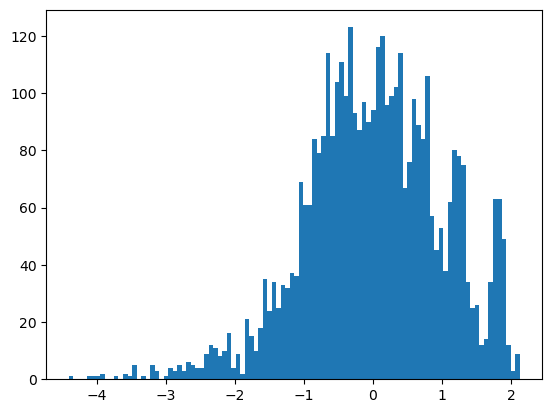

In [7]:
print(np.sum(tc_list == 0))
plt.hist((np.log(tc_list)-1.7)/1.5, bins=100)
plt.show()

In [8]:
import numpy as np
from pymatgen.analysis.local_env import VoronoiNN, LocalStructOrderParams
from pymatgen.analysis.bond_valence import BVAnalyzer


# ─── Oxidation-state decoration (best-effort) ────────────────────────────────

def try_decorate_oxidation(structure):
    """Try to assign oxidation states via bond-valence analysis.
    Returns the decorated structure, or the original if it fails."""
    try:
        bv = BVAnalyzer()
        return bv.get_oxi_state_decorated_structure(structure)
    except Exception:
        return structure


# ─── Local environment analysis (best-effort) ────────────────────────────────

def compute_local_env(structure):
    """
    Returns per-site dicts with:
      - coordination_number  (float)
      - order_params         (list of 5 floats: cn, tet, oct, sq, bent)
      - voronoi_volume       (float)
      - mean_solid_angle     (float)
      - std_solid_angle      (float)
      - mean_face_area       (float)
    Falls back to zeros on failure.
    """
    n = len(structure)
    zero_env = {
        "coordination_number": 0.0,
        "order_params":        [0.0] * 5,
        "voronoi_volume":      0.0,
        "mean_solid_angle":    0.0,
        "std_solid_angle":     0.0,
        "mean_face_area":      0.0,
    }

    try:
        vnn   = VoronoiNN(compute_adj_neighbors=False)
        lsop  = LocalStructOrderParams(["cn", "tet", "oct", "sq", "bent"])
        results = []

        for i in range(n):
            try:
                poly  = vnn.get_voronoi_polyhedra(structure, i)  # {site: stats_dict}
                stats = list(poly.values())

                cn           = float(len(stats))
                solid_angles = np.array([s["solid_angle"] for s in stats])
                face_areas   = np.array([s["area"]        for s in stats])
                volume       = float(sum(s["volume"] for s in stats))

                op = lsop.get_order_parameters(structure, i)
                op = [v if v is not None else 0.0 for v in op]

                results.append({
                    "coordination_number": cn,
                    "order_params":        op,
                    "voronoi_volume":      volume,
                    "mean_solid_angle":    float(solid_angles.mean()),
                    "std_solid_angle":     float(solid_angles.std()),
                    "mean_face_area":      float(face_areas.mean()),
                })
            except Exception:
                results.append(zero_env.copy())

        return results

    except Exception:
        return [zero_env.copy() for _ in range(n)]


# ─── Per-element scalar features ─────────────────────────────────────────────

def _elem_features(elem):
    """Extract scalar features from a pymatgen Element/Species object.
    All values are cast to float; missing values become 0.0."""
    def safe(val):
        try:
            return float(val) if val is not None else 0.0
        except Exception:
            return 0.0

    # Oxidation state (present only on Species, not bare Element)
    ox = safe(getattr(elem, "oxi_state", 0.0))

    # Oxidation state range (proxy for chemical versatility)
    ox_states = list(elem.common_oxidation_states) if elem.common_oxidation_states else [0]
    ox_range  = float(max(ox_states) - min(ox_states))

    return [
        # Identity
        safe(elem.Z),                       # atomic number
        safe(elem.atomic_mass),             # atomic mass  (u)
        # Size
        safe(elem.atomic_radius),           # atomic radius (Å)
        safe(elem.average_ionic_radius),    # avg ionic radius (Å)
        # Chemistry
        safe(elem.X),                       # Pauling electronegativity
        safe(elem.max_oxidation_state),     # max ox. state
        safe(elem.min_oxidation_state),     # min ox. state
        ox,                                 # assigned ox. state (0 if unknown)
        ox_range,                           # ox. state range

    ]

# Total length of _elem_features output — update if you add/remove entries
N_ELEM_FEATURES = 9


# ─── Main feature builder ─────────────────────────────────────────────────────

def get_atom_features_v1(structure):
    """
    Build a node feature matrix for `structure`.

    Feature layout (per node):
    ┌─────────────────────────────────┬────────┐
    │ Elemental features              │  9     │
    │ Occupancy                       │  1     │
    │ Site disorder (entropy)         │  1     │
    │ Fractional coordinates          │  3     │
    │ Coordination number             │  1     │
    │ Order params (cn/tet/oct/sq/bent│  5     │
    │ Voronoi volume                  │  1     │
    │ Mean solid angle                │  1     │
    │ Std  solid angle                │  1     │
    │ Mean face area                  │  1     │
    ├─────────────────────────────────┼────────┤
    │ Total                           │ 33     │
    └─────────────────────────────────┴────────┘

    Returns
    -------
    np.ndarray of shape (n_sites, 33), dtype float32
    """
    # Best-effort oxidation-state decoration
    structure = try_decorate_oxidation(structure)

    # Pre-compute local environment for all sites
    local_env = compute_local_env(structure)

    features = []

    for i, site in enumerate(structure):
        env = local_env[i]

        # ── Structural / site descriptors (same for ordered & disordered) ──
        frac    = list(site.frac_coords)                          # (3,)
        cn      = [env["coordination_number"]]                    # (1,)
        op      = env["order_params"]                             # (5,)
        voro    = [
            env["voronoi_volume"],
            env["mean_solid_angle"],
            env["std_solid_angle"],
            env["mean_face_area"],
        ]                                                         # (4,)

        # ── Elemental descriptors ──────────────────────────────────────────
        if site.is_ordered:
            elem      = site.species.elements[0]
            elem_feat = _elem_features(elem)
            occupancy = 1.0
            disorder  = 0.0

        else:
            # Weighted average of elemental features over species
            occupancies = list(site.species.values())
            disorder    = -sum(o * np.log(o + 1e-9) for o in occupancies)
            occupancy   = max(occupancies)

            elem_feat   = np.zeros(N_ELEM_FEATURES, dtype=np.float64)
            for elem, occ in site.species.items():
                elem_feat += occ * np.array(_elem_features(elem), dtype=np.float64)
            elem_feat = elem_feat.tolist()

        # ── Concatenate all blocks ─────────────────────────────────────────
        node = [
            *elem_feat,       # 18
            occupancy,        #  1
            disorder,         #  1
            *frac,            #  3
            *cn,              #  1
            *op,              #  5
            *voro,            #  4
        ]                     # = 33 total

        features.append(node)

    return np.array(features, dtype=np.float32)



In [9]:
import os

# 1. Strip the bad path and keep only the filename
filename = os.path.basename(data.loc[0, 'cif'])

# 2. Safely join path_red + "cifs" folder + filename
full_local_path = os.path.join(path_red, "cifs", filename)

# 3. Load the structure and graph
structure = Structure.from_file(full_local_path)
graph = structure_to_graph(structure, target=2.64)

print("Graph generated successfully!")
print(structure.get_all_neighbors(4, include_index=True))

NameError: name 'structure_to_graph' is not defined

In [10]:
import os
import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure

# Gaussian basis expansion for bond distances (like CGCNN)
def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

def get_atom_features(structure):
    features = []
    for site in structure:
        if site.is_ordered:
            elem = site.specie
            features.append([
                float(elem.Z),
                float(elem.atomic_mass),
                float(elem.atomic_radius) if elem.atomic_radius else 0.0,
                float(elem.X) if elem.X else 0.0,          # electronegativity
                float(elem.row),                            # period in periodic table
                float(elem.group),                         # group in periodic table
                1.0,                                        # occupancy (fully occupied)
                0.0,                                        # disorder: 0 = pure site
            ])
        else:
            Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
            # measure of disorder (like entropy)
            occupancies = list(site.species.values())
            disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)
            
            for elem, occ in site.species.items():
                Z      += occ * float(elem.Z)
                mass   += occ * float(elem.atomic_mass)
                radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
                X      += occ * (float(elem.X) if elem.X else 0.0)
                row    += occ * float(elem.row)
                group  += occ * float(elem.group)

            features.append([Z, mass, radius, X, row, group,
                              max(occupancies),  # dominant occupancy
                              disorder])         # site disorder

    return np.array(features, dtype=np.float32)

def structure_to_graph(structure, target):
    # Node features
    a, b, c = structure.lattice.abc
    cutoff = 1.2 * min(a, b, c)
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Find neighbors within cutoff
    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    # --- adaptive neighbour cutoff: 1.2 × nearest-neighbour distance ---
    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        if not neighbors:
            continue

        nearest_dist = min(nbr[1] for nbr in neighbors)
        adaptive_cutoff = 1.2 * nearest_dist

        for neighbor in neighbors:
            if neighbor[1] <= adaptive_cutoff:
                edge_src.append(i)
                edge_dst.append(neighbor[2])
                edge_distances.append(neighbor[1])

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)

    # Edge features: Gaussian expanded distances
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)

    # Target value
    y = torch.tensor([target], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

# ==========================================
# --- CORRECTED FILE LOADING & EXECUTION ---
# ==========================================

# 1. Strip the bad path and keep only the filename
filename = os.path.basename(data.loc[0, 'cif'])

# 2. Safely join path_red + "cifs" folder + filename
full_local_path = os.path.join(path_red, "cifs", filename)

# 3. Load the structure and graph
print(f"Loading from: {full_local_path}")
structure = Structure.from_file(full_local_path)
graph = structure_to_graph(structure, target=2.64)

print("\n✅ Graph generated successfully!")
print(graph)

Loading from: /Users/geraldinedeblock_1/Documents/UCPH/applied_machine_learning/final_project/neural_network_algo/cif_file_folder/MP/cifs/Ag0.02Ge2Pd1.98Sr1-MP-mp-978986-synth_doped.cif

✅ Graph generated successfully!
Data(x=[5, 8], edge_index=[2, 36], edge_attr=[36, 40], y=[1])


In [11]:
import os

# 1. Strip the bad path and keep only the raw filename
clean_filename = os.path.basename(data.loc[0, 'cif'])

# 2. Build the correct path to your local 'cifs' folder
full_local_path = os.path.join(path_red, "cifs", clean_filename)

# 3. Load the structure and generate the graph
structure = Structure.from_file(full_local_path)
graph = structure_to_graph(structure, target=2.64)

# 4. Print results
print("Graph generated successfully!")
print(structure.get_all_neighbors(8, include_index=True))

Graph generated successfully!
[[PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, -1.382) [-0.25, -0.75, -0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, -1.382) [-0.75, -0.25, -0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, -3.259) [-0.3706, -0.3706, -0.7411], PeriodicNeighbor: Sr0 (Sr) (-3.481, -4.076, -2.764) [-1.0, -1.0, -1.0], PeriodicNeighbor: Ge1 (Ge) (-2.191, -2.566, -5.535) [-0.6294, -0.6294, -1.259], PeriodicNeighbor: Ge1 (Ge) (-0.6433, -5.587, -1.625) [-0.3706, -1.371, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-1.544, -6.642, -3.902) [-0.6294, -1.629, -1.259], PeriodicNeighbor: Ge1 (Ge) (-5.417, -1.511, -1.625) [-1.371, -0.3706, -0.7411], PeriodicNeighbor: Ge1 (Ge) (-6.318, -2.566, -3.902) [-1.629, -0.6294, -1.259], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-0.5469, -3.057, 4.649) [-0.25, -0.75, 0.5], PeriodicNeighbor: Ag3 (Ag:0.01, Pd:0.99) (-2.934, -1.019, 4.649) [-0.75, -0.25, 0.5], PeriodicNeighbor: Ge1 (Ge) (-1.29, -1.511, 2.772) [-0.3706, -0.3706

In [26]:
import os
import numpy as np
import torch
from pymatgen.core import Structure

graphs = []

for i, row in data.iterrows():
    try:
        # 1. Strip the bad path and keep ONLY the raw filename
        clean_filename = os.path.basename(row['cif'])
        
        # 2. Safely build the correct local path for this specific row
        full_local_path = os.path.join(path_red, "cifs", clean_filename)
        
        # 3. Load the structure
        structure = Structure.from_file(full_local_path)
        
        # 4. Generate the graph (if Tc > 0)
        if row['tc'] > 0:
            graph = structure_to_graph(structure, target=(np.log(row['tc']) - 2) / 1.5)
            graphs.append(graph)
            
    except Exception as e:
        # This will print the exact reason it failed, rather than just silently skipping
        print(f"Skipping row {i}: {e}")

print(f"\n✅ Built {len(graphs)} graphs")

if len(graphs) > 0:
    print("Inspecting the first graph:")
    print(graphs[0])  
    torch.save(graphs, 'crystal_graphs_v1.pt')
    print("Saved to 'crystal_graphs_v1.pt'")
else:
    print("❌ No graphs were built. Check the error messages above.")

/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal valu


✅ Built 3995 graphs
Inspecting the first graph:
Data(x=[5, 8], edge_index=[2, 36], edge_attr=[36, 40], y=[1])
Saved to 'crystal_graphs_v1.pt'


In [12]:
import os
import numpy as np
import torch
from torch_geometric.data import Data
from pymatgen.core import Structure
import matgl
from tqdm import tqdm

# ── 1. DEFINING THE FUNCTIONS ─────────────────────────────────────────

def gaussian_expansion(distances, dmin=0, dmax=8, steps=40):
    filters = np.linspace(dmin, dmax, steps)
    sigma = (dmax - dmin) / steps
    return np.exp(-((distances[:, None] - filters[None, :]) ** 2) / sigma ** 2)

def get_atom_features(structure):
    features = []
    for site in structure:
        if site.is_ordered:
            elem = site.species.elements[0] 
            features.append([
                float(elem.Z), float(elem.atomic_mass),
                float(elem.atomic_radius) if elem.atomic_radius else 0.0,
                float(elem.X) if elem.X else 0.0,          
                float(elem.row), float(elem.group),                         
                1.0, 0.0,                                        
            ])
        else:
            Z, mass, radius, X, row, group = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
            occupancies = list(site.species.values())
            disorder = -sum(o * np.log(o + 1e-9) for o in occupancies)
            
            for elem, occ in site.species.items():
                Z      += occ * float(elem.Z)
                mass   += occ * float(elem.atomic_mass)
                radius += occ * (float(elem.atomic_radius) if elem.atomic_radius else 0.0)
                X      += occ * (float(elem.X) if elem.X else 0.0)
                row    += occ * float(elem.row)
                group  += occ * float(elem.group)

            features.append([Z, mass, radius, X, row, group, max(occupancies), disorder])         
    return np.array(features, dtype=np.float32)

def structure_to_graph(structure, target):
    a, b, c = structure.lattice.abc
    cutoff = 1.2 * min(a, b, c)
    atom_feats = get_atom_features(structure)
    x = torch.tensor(atom_feats, dtype=torch.float)

    all_neighbors = structure.get_all_neighbors(cutoff, include_index=True)

    edge_src, edge_dst, edge_distances = [], [], []
    for i, neighbors in enumerate(all_neighbors):
        if not neighbors: continue
        nearest_dist = min(nbr[1] for nbr in neighbors)
        adaptive_cutoff = 1.2 * nearest_dist
        for neighbor in neighbors:
            if neighbor[1] <= adaptive_cutoff:
                edge_src.append(i)
                edge_dst.append(neighbor[2])
                edge_distances.append(neighbor[1])

    edge_index = torch.tensor(np.array([edge_src, edge_dst]), dtype=torch.long)
    distances = np.array(edge_distances)
    edge_attr = torch.tensor(gaussian_expansion(distances), dtype=torch.float)
    y = torch.tensor([target], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# ── 2. LOADING MATGL AND RUNNING THE LOOP ─────────────────────────────

print("Loading pre-trained MatGL MEGNet...")
megnet = matgl.load_model("MEGNet-Eform-MP-2018.6.1")

graphs = []
failed_count = 0

print("Building PyG graphs AND calculating MatGL physical anchors...")
for i, row in tqdm(data.iterrows(), total=len(data)):
    try:
        clean_filename = os.path.basename(row['cif'])
        full_local_path = os.path.join(path_red, "cifs", clean_filename)
        
        structure = Structure.from_file(full_local_path)
        
        if row['tc'] > 0:
            # 1. Generate the custom graph using the TRUE fractional structure
            graph = structure_to_graph(structure, target=(np.log(row['tc']) - 2) / 1.5)
            
            # 2. CREATE ORDERED APPROXIMATION FOR MATGL
            # MatGL crashes on fractional occupancies, so we temporarily round to the majority element
            ordered_struct = structure.copy()
            for j, site in enumerate(ordered_struct):
                if not site.is_ordered:
                    # Find the element with the highest occupancy fraction
                    majority_elem = max(site.species.items(), key=lambda x: x[1])[0]
                    ordered_struct.replace(j, majority_elem)
            
            # 3. Predict the formation energy using the ordered approximation
            e_form = megnet.predict_structure(ordered_struct).item()
            
            # 4. Attach the pre-trained knowledge directly to the graph!
            graph.matgl_feat = torch.tensor([e_form], dtype=torch.float32)
            
            graphs.append(graph)
            
    except Exception as e:
        failed_count += 1
        # Only print the exact reason if it fails on something completely different
        if failed_count == 1:
            print(f"\n--- EXACT ERROR ---")
            print(f"{type(e).__name__}: {e}\n")

print(f"\n✅ Successfully built {len(graphs)} graphs with MatGL features attached!")
if failed_count > 0:
    print(f"Failed to load {failed_count} CIFs (likely missing/corrupt files).")

Loading pre-trained MatGL MEGNet...


/opt/anaconda3/lib/python3.13/site-packages/matgl/utils/io.py:182: UserWarning: Incompatible model version detected! The code will continue to load the model but it is recommended that you provide a path to an updated model, increment your @model_version in model.json if you are confident that the changes are not problematic, or clear your ~/.matgl cache using `python -c "import matgl; matgl.clear_cache()"`
  _check_ver(cls_, v)  # Check version of any subclasses too.


Building PyG graphs AND calculating MatGL physical anchors...


  0%|                                                  | 0/5773 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  0%|                                         | 10/5773 [00:00<01:07, 85.33it/s]/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/opt/anaconda3/lib/python3.13/site-packages/pymatgen/core/structure.py:3172: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
  1%|▏        


✅ Successfully built 3995 graphs with MatGL features attached!


In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from pymatgen.core import Element

def draw_crystal_graph(data, structure, title="Crystal Graph"):
    
    # Build networkx graph
    G = nx.Graph()
    
    # Add nodes
    num_atoms = data.x.shape[0]
    for i in range(num_atoms):
        G.add_node(i)
    
    # Add edges (avoid duplicate edges since graph is undirected)
    edge_index = data.edge_index.numpy()
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        if src < dst:  # avoid duplicates
            G.add_edge(src, dst)
    
    # Get atom labels and colors for each node
    labels = {}
    colors = []
    color_map = {}  # map element symbol to color
    cmap = plt.cm.get_cmap("tab20")
    color_idx = 0

    for i, site in enumerate(structure):
        if site.is_ordered:
            symbol = site.specie.symbol
        else:
            # Use dominant element for label
            symbol = max(site.species, key=site.species.get).symbol
            symbol = symbol + "*"  # mark doped sites with asterisk
        
        labels[i] = symbol
        
        if symbol not in color_map:
            color_map[symbol] = cmap(color_idx % 20)
            color_idx += 1
        colors.append(color_map[symbol])
    
    # Draw
    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="white", ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)
    
    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=10, label=symbol)
        for symbol, color in color_map.items()
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    ax.set_title(f"{title}\n{data.x.shape[0]} atoms, {G.number_of_edges()} bonds, Tc={data.y.item():.1f} K")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Full Formula (La2 Al3.99 Si0.01)
Reduced Formula: La2Al3.99Si0.01
abc   :   5.758103   5.758103   5.758103
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (6)
  #  SP                       a      b      c
---  -------------------  -----  -----  -----
  0  La                   0      0      0
  1  La                   0.75   0.75   0.75
  2  Al:0.998, Si:0.0025  0.375  0.375  0.375
  3  Al:0.998, Si:0.0025  0.375  0.375  0.875
  4  Al:0.998, Si:0.0025  0.375  0.875  0.375
  5  Al:0.998, Si:0.0025  0.875  0.375  0.375 Al1.995La1Si0.005-MP-mp-2694-synth_doped.cif


/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_88670/1556959492.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


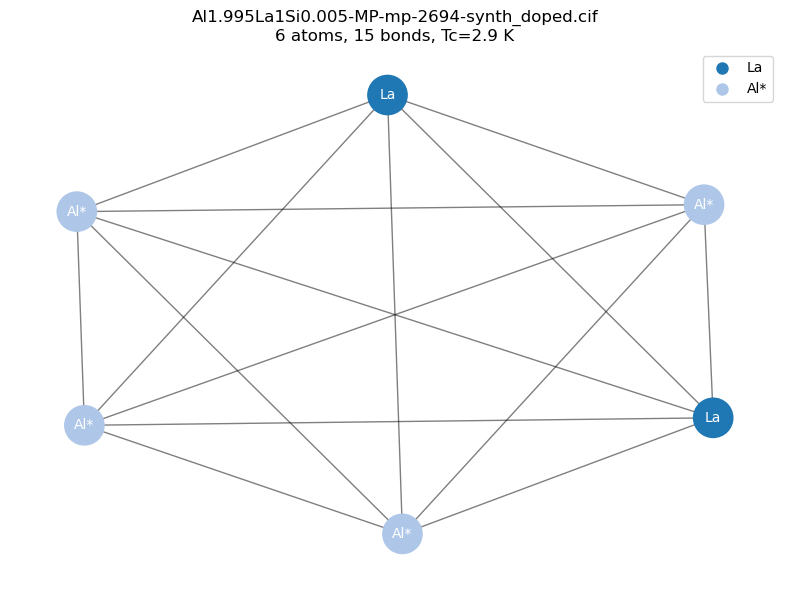

In [14]:
import os

i = 200

# 1. Strip the bad path to get just the filename
clean_filename = os.path.basename(data.loc[i, 'cif'])

# 2. Safely build the local path
full_local_path = os.path.join(path_red, "cifs", clean_filename)

# 3. Load, convert, and plot!
structure = Structure.from_file(full_local_path)
print(structure, clean_filename)

graph = structure_to_graph(structure, target=data.loc[i, 'tc'])
draw_crystal_graph(graph, structure, title=clean_filename)

In [15]:
from sklearn.model_selection import KFold

In [16]:
import matgl
import torch
from tqdm import tqdm

print("1. Loading pre-trained MatGL MEGNet...")
# FIXED: Using the correct Hugging Face repository name
megnet = matgl.load_model("MEGNet-Eform-MP-2018.6.1")

print("2. Calculating physical anchor features for all graphs...")
# This assumes you have a list of pymatgen 'structures' that perfectly 
# matches the order of your PyTorch Geometric 'graphs' list.
for i in tqdm(range(len(graphs))):
    struct = structures[i]
    
    # Let MatGL predict the formation energy
    e_form = megnet.predict_structure(struct).item()
    
    # Save this feature directly inside the PyTorch Geometric Data object.
    graphs[i].matgl_feat = torch.tensor([e_form], dtype=torch.float32)

print("\nSuccess! MatGL features injected into PyG graphs.")

1. Loading pre-trained MatGL MEGNet...
2. Calculating physical anchor features for all graphs...


  0%|                                                  | 0/3995 [00:00<?, ?it/s]


NameError: name 'structures' is not defined

In [36]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np

class CGCNN(nn.Module):
    def __init__(self, node_features=8, edge_features=40, 
                 hidden_dim=64, num_conv_layers=3, dropout=0.1):
        super(CGCNN, self).__init__()
        
        # Initial embedding of node features
        self.node_embedding = nn.Linear(node_features, hidden_dim)
        
        # Graph convolutional layers
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim, dim=edge_features, batch_norm=True)
            for _ in range(num_conv_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Readout MLP
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        
        # Embed node features
        x = self.node_embedding(x)
        x = torch.relu(x)
        
        # Graph convolutions
        for conv in self.conv_layers:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
            x = self.dropout(x)
        
        # Global pooling: aggregate all atoms into one vector
        x = global_mean_pool(x, batch)
        
        # Predict
        out = self.fc(x)
        return out.squeeze(-1)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        
        y = batch.y.view(-1)  # flatten to 1D
        
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            
            # Use squeeze(-1) to only squeeze the last dimension
            y = batch.y.view(-1)  # flatten to 1D regardless of shape
            
            loss = criterion(pred, y)
            total_loss += loss.item()
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())
    
    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))
    return total_loss / len(loader), mae


def train_cgcnn_kfold(graphs, k_folds=5, hidden_dim=64, num_conv_layers=3, 
                      epochs=50, batch_size=32, lr=1e-3):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Initialize KFold
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    node_features = graphs[0].x.shape[1]
    edge_features = graphs[0].edge_attr.shape[1]
    
    fold_maes = []
    
    # Loop through each fold
    for fold, (train_idx, val_idx) in enumerate(kfold.split(graphs)):
        print(f"\n{'='*30}\nFold {fold + 1}/{k_folds}\n{'='*30}")
        
        # 1. Create DataLoaders for this specific fold
        train_sub = [graphs[i] for i in train_idx]
        val_sub   = [graphs[i] for i in val_idx]
        
        train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_sub, batch_size=batch_size)

        # 2. RE-INITIALIZE THE MODEL AND OPTIMIZER! (Crucial to avoid data leakage)
        model = CGCNN(
            node_features=node_features,
            edge_features=edge_features,
            hidden_dim=hidden_dim,
            num_conv_layers=num_conv_layers
        ).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = StepLR(optimizer, step_size=30, gamma=0.5)
        criterion = nn.MSELoss()

        best_val_loss = float('inf')
        best_val_mae = float('inf')

        # 3. Train the model for this fold
        for epoch in range(epochs):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_mae = evaluate(model, val_loader, criterion, device)
            scheduler.step()

            # Save the best MAE for this fold
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_mae = val_mae
                # Optional: Save the best weights for THIS specific fold
                torch.save(model.state_dict(), f'cgcnn_model_fold_{fold+1}.pt')

        print(f"Fold {fold + 1} finished! Best Val MAE: {best_val_mae:.4f}")
        fold_maes.append(best_val_mae)

    # 4. Summarize Results
    avg_mae = np.mean(fold_maes)
    std_mae = np.std(fold_maes)
    
    print(f"\n✅ K-Fold Cross Validation Complete!")
    print(f"Average Validation MAE across {k_folds} folds: {avg_mae:.4f} ± {std_mae:.4f}")
    
    return avg_mae, fold_maes

In [41]:
# ── 1. RUN CROSS VALIDATION ───────────────────────────────────────────────
print("Starting 5-Fold Cross Validation... Grab a coffee, this will take 5x longer!")

# Run the K-Fold
average_mae, all_fold_maes = train_cgcnn_kfold(graphs, k_folds=5, epochs=50)

print("CV Results:", all_fold_maes)

# ── 2. TRAIN FINAL PRODUCTION MODEL ───────────────────────────────────────
print("\nTraining final model on ALL data for production...")
final_loader = DataLoader(graphs, batch_size=32, shuffle=True)

# DYNAMICALLY grab the correct feature sizes from your actual data!
n_features = graphs[0].x.shape[1]
e_features = graphs[0].edge_attr.shape[1]

# Initialize with the correct dynamic sizes
final_model = CGCNN(
    node_features=n_features, 
    edge_features=e_features, 
    hidden_dim=64, 
    num_conv_layers=3
).to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

final_model.train()
for epoch in range(50):
    train_epoch(final_model, final_loader, optimizer, criterion, device)

# Save the ultimate final model
torch.save(final_model.state_dict(), 'cgcnn_final_production.pt')
print("✅ Final model saved as 'cgcnn_final_production.pt'!")

final_model.eval()

Starting 5-Fold Cross Validation... Grab a coffee, this will take 5x longer!
Using device: cpu

Fold 1/5
Fold 1 finished! Best Val MAE: 0.4034

Fold 2/5
Fold 2 finished! Best Val MAE: 0.4075

Fold 3/5
Fold 3 finished! Best Val MAE: 0.3815

Fold 4/5
Fold 4 finished! Best Val MAE: 0.4069

Fold 5/5
Fold 5 finished! Best Val MAE: 0.4131

✅ K-Fold Cross Validation Complete!
Average Validation MAE across 5 folds: 0.4025 ± 0.0109
CV Results: [np.float32(0.40342554), np.float32(0.40749142), np.float32(0.38153365), np.float32(0.40690306), np.float32(0.4130689)]

Training final model on ALL data for production...
✅ Final model saved as 'cgcnn_final_production.pt'!


CGCNN(
  (node_embedding): Linear(in_features=8, out_features=64, bias=True)
  (conv_layers): ModuleList(
    (0-2): 3 x CGConv(64, dim=40)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [17]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np

# NEW: Import train_test_split to create the 10% hold-out set
from sklearn.model_selection import KFold, train_test_split

import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np

class CGCNN(nn.Module):
    def __init__(self, node_features=8, edge_features=40, 
                 hidden_dim=64, num_conv_layers=3, dropout=0.1):
        super(CGCNN, self).__init__()
        
        self.node_embedding = nn.Linear(node_features, hidden_dim)
        
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim, dim=edge_features, batch_norm=True)
            for _ in range(num_conv_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # --- STRATEGY 1 MODIFICATION ---
        # We add "+ 1" to the input of this layer because we are combining 
        # the graph's hidden_dim (64) with the 1D MatGL formation energy feature.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        
        x = self.node_embedding(x)
        x = torch.relu(x)
        
        for conv in self.conv_layers:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
            x = self.dropout(x)
        
        # Aggregate all atoms into one vector of size [batch_size, hidden_dim]
        x = global_mean_pool(x, batch)
        
        # --- STRATEGY 1 MODIFICATION ---
        # Extract the batched MatGL features and ensure shape is [batch_size, 1]
        matgl_f = data.matgl_feat.view(-1, 1)
        
        # Concatenate the graph's learned embedding with the MatGL knowledge
        combined_x = torch.cat([x, matgl_f], dim=1)
        
        # Predict using the combined vector
        out = self.fc(combined_x)
        return out.squeeze(-1)

# (Keep your train_epoch, evaluate, and train_cgcnn_kfold functions exactly as they are below this class)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        
        y = batch.y.view(-1)  # flatten to 1D
        
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            
            # Use squeeze(-1) to only squeeze the last dimension
            y = batch.y.view(-1)  # flatten to 1D regardless of shape
            
            loss = criterion(pred, y)
            total_loss += loss.item()
            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())
    
    mae = np.mean(np.abs(np.array(preds) - np.array(targets)))
    return total_loss / len(loader), mae


def train_evaluate_pipeline(graphs, test_size=0.10, k_folds=5, hidden_dim=64, 
                            num_conv_layers=3, epochs=50, batch_size=32, lr=1e-3):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # ---------------------------------------------------------
    # 1. SPLIT DATA: 90% Train/Val (for CV) | 10% Hold-out Test
    # ---------------------------------------------------------
    train_val_graphs, test_graphs = train_test_split(graphs, test_size=test_size, random_state=42)
    print(f"Total graphs: {len(graphs)} | 90% CV Set: {len(train_val_graphs)} | 10% Test Set: {len(test_graphs)}")
    
    node_features = graphs[0].x.shape[1]
    edge_features = graphs[0].edge_attr.shape[1]
    
    # ---------------------------------------------------------
    # 2. K-FOLD CROSS VALIDATION (Only on the 90% set)
    # ---------------------------------------------------------
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_maes = []
    
    print("\n--- Starting K-Fold Cross Validation ---")
    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_val_graphs)):
        print(f"\nFold {fold + 1}/{k_folds}")
        
        # Sub-split the 90% data into this fold's Train and Val
        train_sub = [train_val_graphs[i] for i in train_idx]
        val_sub   = [train_val_graphs[i] for i in val_idx]
        
        train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_sub, batch_size=batch_size)

        # Initialize model & optimizer fresh for each fold
        model = CGCNN(node_features=node_features, edge_features=edge_features, 
                      hidden_dim=hidden_dim, num_conv_layers=num_conv_layers).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = StepLR(optimizer, step_size=30, gamma=0.5)
        criterion = nn.MSELoss()

        best_val_loss = float('inf')
        best_val_mae = float('inf')

        # Train fold
        for epoch in range(epochs):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_mae = evaluate(model, val_loader, criterion, device)
            scheduler.step()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_mae = val_mae

        print(f"Fold {fold + 1} finished! Best Val MAE: {best_val_mae:.4f}")
        fold_maes.append(best_val_mae)

    avg_mae = np.mean(fold_maes)
    std_mae = np.std(fold_maes)
    print(f"\n✅ CV Complete! Average Validation MAE: {avg_mae:.4f} ± {std_mae:.4f}")
    
    # ---------------------------------------------------------
    # 3. FINAL MODEL: Train on 100% of the 90% CV Data
    # ---------------------------------------------------------
    print("\n--- Training Final Production Model ---")
    final_train_loader = DataLoader(train_val_graphs, batch_size=batch_size, shuffle=True)
    test_loader        = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    final_model = CGCNN(node_features=node_features, edge_features=edge_features, 
                        hidden_dim=hidden_dim, num_conv_layers=num_conv_layers).to(device)
    
    final_optimizer = torch.optim.Adam(final_model.parameters(), lr=lr)
    final_scheduler = StepLR(final_optimizer, step_size=30, gamma=0.5)

    final_model.train()
    for epoch in range(epochs):
        train_epoch(final_model, final_train_loader, final_optimizer, criterion, device)
        final_scheduler.step()
        
    torch.save(final_model.state_dict(), 'cgcnn_final_production.pt')
    print("Final model saved as 'cgcnn_final_production.pt'")

    # ---------------------------------------------------------
    # 4. ULTIMATE TEST: Evaluate on the pristine 10% Test Set
    # ---------------------------------------------------------
    test_loss, test_mae = evaluate(final_model, test_loader, criterion, device)
    print(f"\n🚀 FINAL HOLD-OUT TEST MAE (Unseen Data): {test_mae:.4f}")
    
    return final_model, test_graphs, avg_mae, test_mae

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ── 1. RUN THE ENTIRE PIPELINE ───────────────────────────────────────────────
print("Starting the ultimate ML pipeline (Split -> CV -> Final Train -> Test)...")

# This single line handles the 10% split, the 5-fold CV, and trains the final model!
final_model, test_graphs, cv_mae, test_mae = train_evaluate_pipeline(
    graphs, test_size=0.10, k_folds=5, epochs=50, batch_size=32
)



Starting the ultimate ML pipeline (Split -> CV -> Final Train -> Test)...
Using device: cpu
Total graphs: 3995 | 90% CV Set: 3595 | 10% Test Set: 400

--- Starting K-Fold Cross Validation ---

Fold 1/5
Fold 1 finished! Best Val MAE: 0.4168

Fold 2/5
Fold 2 finished! Best Val MAE: 0.3952

Fold 3/5
Fold 3 finished! Best Val MAE: 0.3911

Fold 4/5
Fold 4 finished! Best Val MAE: 0.3987

Fold 5/5
Fold 5 finished! Best Val MAE: 0.4138

✅ CV Complete! Average Validation MAE: 0.4031 ± 0.0103

--- Training Final Production Model ---
Final model saved as 'cgcnn_final_production.pt'

🚀 FINAL HOLD-OUT TEST MAE (Unseen Data): 0.4053



Generating final plot for the 10% unseen test set...


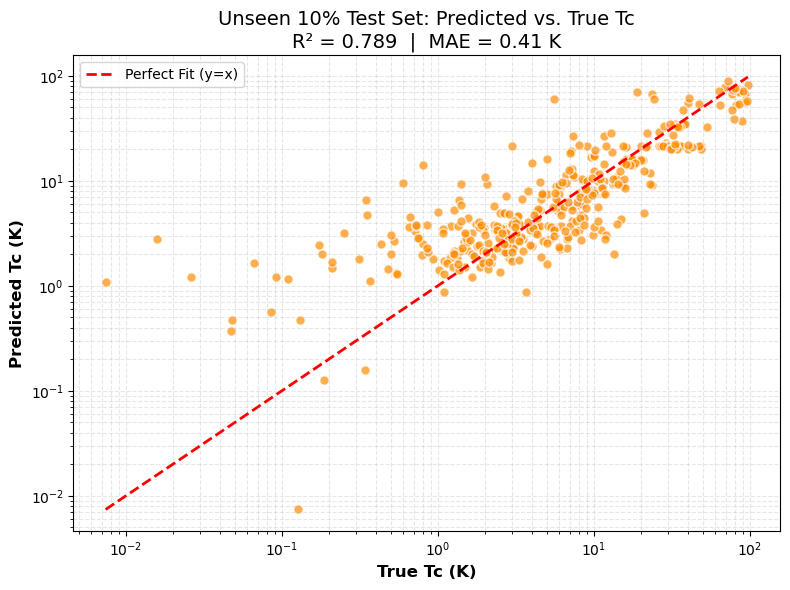

In [19]:
# ── 2. GATHER PREDICTIONS FOR THE PLOT ───────────────────────────────────────
print("\nGenerating final plot for the 10% unseen test set...")

# Load just the pristine 10% test data
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)
preds, targets = [], []

final_model.eval()

# --- ADDED: Define device in this cell's scope ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model = final_model.to(device) # Ensure model is on the right device

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = final_model(batch)
        preds.extend(pred.cpu().numpy().flatten())
        targets.extend(batch.y.cpu().numpy().flatten())

preds = np.array(preds)
targets = np.array(targets)

# Revert normalization back to real-world Kelvin
true_tc = np.exp((targets * 1.5) + 2)
pred_tc = np.exp((preds * 1.5) + 2)

# Calculate R²
r2 = r2_score(true_tc, pred_tc)
# ── 3. DRAW THE PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# Plot the predictions in orange
plt.scatter(true_tc, pred_tc, alpha=0.7, color='darkorange', edgecolors='w', s=45)

# Draw the red "perfect fit" y=x diagonal line
min_val = min(true_tc.min(), pred_tc.min())
max_val = max(true_tc.max(), pred_tc.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Fit (y=x)")

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Tc (K)", fontsize=12, fontweight='bold')
plt.ylabel("Predicted Tc (K)", fontsize=12, fontweight='bold')
plt.title(f"Unseen 10% Test Set: Predicted vs. True Tc\nR² = {r2:.3f}  |  MAE = {test_mae:.2f} K", fontsize=14)
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

R² Score: 0.789
RMSE: 9.16 K


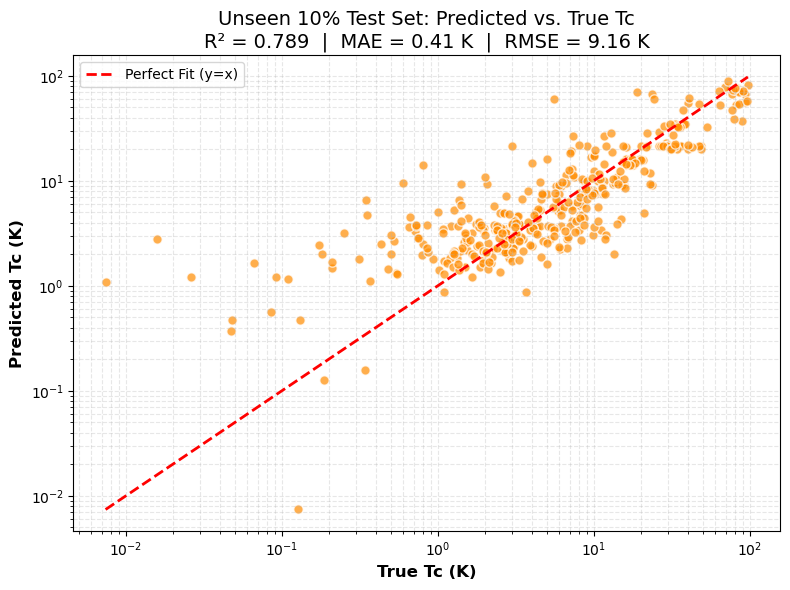

In [20]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# ... [Your existing data loading and prediction loop] ...

preds = np.array(preds)
targets = np.array(targets)

# Revert normalization back to real-world Kelvin
true_tc = np.exp((targets * 1.5) + 2)
pred_tc = np.exp((preds * 1.5) + 2)

# ── NEW METRICS CALCULATION ──────────────────────────────────────────────────
# Calculate R²
r2 = r2_score(true_tc, pred_tc)

# Calculate RMSE (Root Mean Squared Error)
mse = mean_squared_error(true_tc, pred_tc)
rmse = np.sqrt(mse)

# Alternatively, using pure NumPy:
# rmse = np.sqrt(np.mean((true_tc - pred_tc)**2))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f} K")

# ── 3. DRAW THE PLOT ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot the predictions in orange
plt.scatter(true_tc, pred_tc, alpha=0.7, color='darkorange', edgecolors='w', s=45)

# Draw the red "perfect fit" y=x diagonal line
min_val = min(true_tc.min(), pred_tc.min())
max_val = max(true_tc.max(), pred_tc.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Fit (y=x)")

# Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel("True Tc (K)", fontsize=12, fontweight='bold')
plt.ylabel("Predicted Tc (K)", fontsize=12, fontweight='bold')

# ADDED: RMSE to the plot title so it displays alongside R2 and MAE
plt.title(f"Unseen 10% Test Set: Predicted vs. True Tc\nR² = {r2:.3f}  |  MAE = {test_mae:.2f} K  |  RMSE = {rmse:.2f} K", fontsize=14)

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout() 
plt.show()

Evaluating final model on all data...

✅ Final Model Fit Metrics:
MAE: 4.46 K
R²:  0.8420


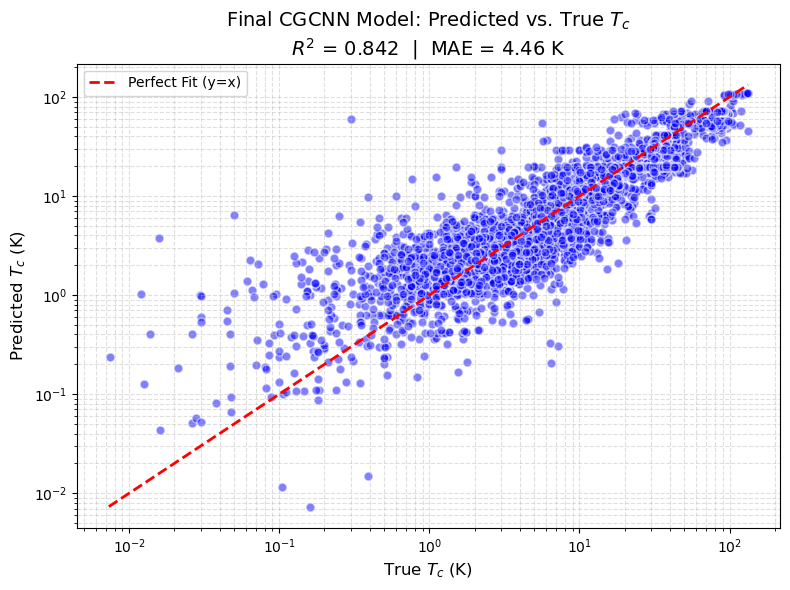

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import torch
from torch_geometric.loader import DataLoader

print("Evaluating final model on all data...")

# 1. Put model in eval mode and create a sequential loader (no shuffling)
final_model.eval()
eval_loader = DataLoader(graphs, batch_size=32, shuffle=False)

# 2. Gather all predictions and true values
preds, targets = [], []
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        pred = final_model(batch)
        preds.extend(pred.cpu().numpy().flatten())
        targets.extend(batch.y.cpu().numpy().flatten())

preds = np.array(preds)
targets = np.array(targets)

# 3. Un-normalize the data back to actual Critical Temperature (Kelvin)
# During graph creation you did: target = (np.log(Tc) - 2) / 1.5
# So the inverse math is: Tc = np.exp((target * 1.5) + 2)
true_tc = np.exp((targets * 1.5) + 2)
pred_tc = np.exp((preds * 1.5) + 2)

# 4. Calculate Metrics
mae = mean_absolute_error(true_tc, pred_tc)
r2 = r2_score(true_tc, pred_tc)

print(f"\n✅ Final Model Fit Metrics:")
print(f"MAE: {mae:.2f} K")
print(f"R²:  {r2:.4f}")

# 5. Create the Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(true_tc, pred_tc, alpha=0.5, color='blue', edgecolors='w', s=40)

# Draw the red "perfect fit" y=x diagonal line
min_val = min(true_tc.min(), pred_tc.min())
max_val = max(true_tc.max(), pred_tc.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Fit (y=x)")

# Formatting the plot
plt.xscale('log') # Log scale is excellent for visualizing superconductors
plt.yscale('log')
plt.xlabel("True $T_c$ (K)", fontsize=12)
plt.ylabel("Predicted $T_c$ (K)", fontsize=12)
plt.title(f"Final CGCNN Model: Predicted vs. True $T_c$\n$R^2$ = {r2:.3f}  |  MAE = {mae:.2f} K", fontsize=14)
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Running permutation importance...
  feature 08/8 done


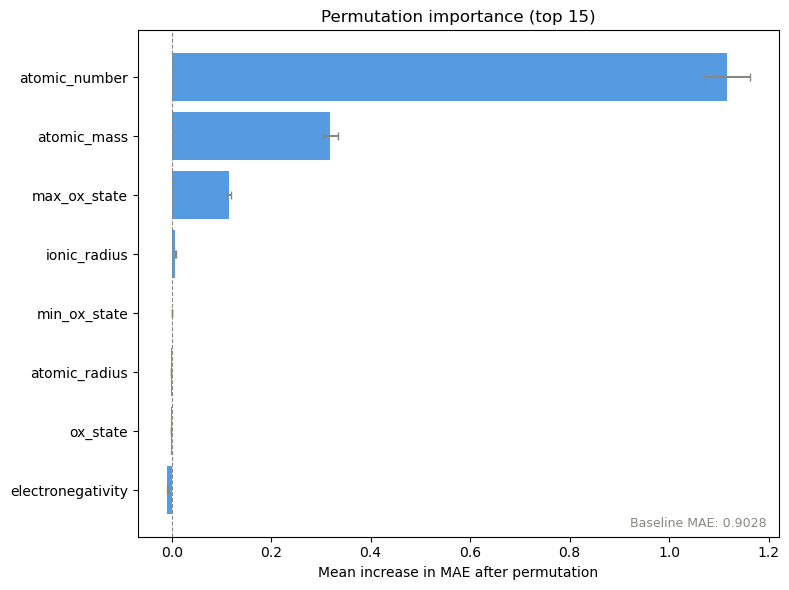


Top 10 features by permutation importance:
   1. atomic_number              +1.1170 ± 0.0455
   2. atomic_mass                +0.3185 ± 0.0151
   3. max_ox_state               +0.1149 ± 0.0038
   4. ionic_radius               +0.0075 ± 0.0004
   5. min_ox_state               -0.0002 ± 0.0000
   6. atomic_radius              -0.0012 ± 0.0006
   7. ox_state                   -0.0015 ± 0.0004
   8. electronegativity          -0.0089 ± 0.0008


In [33]:
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

# ── Feature names (update if you changed get_atom_features) ──────────────────
FEATURE_NAMES = [
    # Elemental
    "atomic_number", "atomic_mass", "atomic_radius", "ionic_radius",
    "electronegativity", "max_ox_state", "min_ox_state", "ox_state", "ox_range",
    # Site
    "occupancy", "disorder",
    # Structural
    "frac_x", "frac_y", "frac_z",
    "coordination_number",
    "op_cn", "op_tet", "op_oct", "op_sq", "op_bent",
    "voronoi_volume", "mean_solid_angle", "std_solid_angle", "mean_face_area",
]

# ── Helper: predict from raw node feature matrix ──────────────────────────────
# Both SHAP and permutation importance work by perturbing node features,
# so we need a function that accepts a plain numpy array and returns predictions.
# We pool perturbed features back into the existing graph structure.

def predict_from_features(feature_matrix, graphs, model, device, batch_size=64):
    """
    feature_matrix : np.ndarray of shape (N_graphs, N_node_features)
                     Each row is the *mean* node feature vector for one graph
                     (we use graph-level mean pooling to get a fixed-size input
                     that SHAP and permutation importance can work with).
    Returns        : np.ndarray of shape (N_graphs,)
    """
    preds = []
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    feat_tensor = torch.tensor(feature_matrix, dtype=torch.float32)

    idx = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            bs = batch.num_graphs

            # Replace each node's features with the perturbed graph-mean
            # by expanding the per-graph vector back to per-node
            sizes    = batch.ptr[1:] - batch.ptr[:-1]           # nodes per graph
            expanded = torch.repeat_interleave(
                feat_tensor[idx:idx+bs].to(device), sizes, dim=0
            )
            batch.x  = expanded
            pred     = model(batch)
            preds.extend(pred.cpu().numpy().flatten())
            idx += bs

    return np.array(preds)


def get_graph_feature_matrix(graphs):
    """Summarise each graph as its mean node feature vector."""
    return np.array([g.x.numpy().mean(axis=0) for g in graphs])


# ══════════════════════════════════════════════════════════════════════════════
# 1. PERMUTATION IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════

def permutation_importance(model, graphs, device, n_repeats=10, batch_size=64):
    """
    For each feature:
      1. Record baseline MAE
      2. Shuffle that feature across all graphs n_repeats times
      3. Importance = mean increase in MAE after shuffling

    A large increase means the model relied heavily on that feature.
    """
    model.eval()
    X        = get_graph_feature_matrix(graphs)
    y        = np.array([g.y.item() for g in graphs])
    baseline = np.mean(np.abs(predict_from_features(X, graphs, model, device, batch_size) - y))

    n_features   = X.shape[1]
    importances  = np.zeros((n_features, n_repeats))

    for f in range(n_features):
        for r in range(n_repeats):
            X_permuted      = X.copy()
            X_permuted[:, f] = np.random.permutation(X_permuted[:, f])
            preds            = predict_from_features(X_permuted, graphs, model, device, batch_size)
            importances[f, r] = np.mean(np.abs(preds - y)) - baseline

        print(f"  feature {f+1:02d}/{n_features} done", end="\r")

    print()
    return {
        "mean":     importances.mean(axis=1),
        "std":      importances.std(axis=1),
        "baseline": baseline,
        "raw":      importances,
    }


# ══════════════════════════════════════════════════════════════════════════════
# 2. SHAP VALUES
# ══════════════════════════════════════════════════════════════════════════════

def compute_shap(model, graphs, device, n_background=50, n_explain=100, batch_size=64):
    """
    Uses KernelSHAP, which is model-agnostic and works with any GNN.
    
    n_background : number of graphs used as the SHAP background (reference) set
    n_explain    : number of graphs to explain (more = slower but stabler values)
    """
    model.eval()
    X = get_graph_feature_matrix(graphs)

    # Wrapper so SHAP can call the model like a plain function
    def model_predict(feature_matrix):
        return predict_from_features(feature_matrix, graphs[:len(feature_matrix)],
                                     model, device, batch_size)

    background = X[:n_background]
    explain    = X[:n_explain]

    explainer   = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(explain, nsamples=100, silent=True)

    return shap_values, explain


# ══════════════════════════════════════════════════════════════════════════════
# 3. PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

def plot_permutation_importance(perm_result, feature_names=FEATURE_NAMES, top_n=15):
    means = perm_result["mean"]
    stds  = perm_result["std"]

    # Sort by importance
    order   = np.argsort(means)[-top_n:]
    names   = [feature_names[i] for i in order]
    m_vals  = means[order]
    s_vals  = stds[order]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(names, m_vals, xerr=s_vals, capsize=3,
                   color="#378ADD", alpha=0.85, ecolor="#888780")
    ax.axvline(0, color="#888780", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Mean increase in MAE after permutation")
    ax.set_title(f"Permutation importance (top {top_n})")
    ax.text(0.98, 0.02, f"Baseline MAE: {perm_result['baseline']:.4f}",
            transform=ax.transAxes, ha="right", fontsize=9, color="#888780")
    plt.tight_layout()
    plt.savefig("permutation_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 4. RUN EVERYTHING
# ══════════════════════════════════════════════════════════════════════════════

model.eval()

print("Running permutation importance...")
perm_result = permutation_importance(model, graphs, device, n_repeats=10)
plot_permutation_importance(perm_result)


# Numeric summary
print("\nTop 10 features by permutation importance:")
order = np.argsort(perm_result["mean"])[::-1]
for rank, i in enumerate(order[:10], 1):
    print(f"  {rank:2d}. {FEATURE_NAMES[i]:<25s}  {perm_result['mean'][i]:+.4f} ± {perm_result['std'][i]:.4f}")
